In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def make_autopct(values):          # 外层函数（接受整个数据）
    '''
    This function sets the autopct for pie charts as I want to appear
    :param values -> the data which is shown in the pie
    '''
    print(values)
    def my_autopct(pct):           # 内层函数（matplotlib 调用）
        print(pct)
        total = sum(values)        # 外层变量 values 被“捕获”进来
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val:d})'
    return my_autopct              # 返回内层函数

In [3]:
def setting_dataframe(df):
    '''
    This function displays the results in an organized dataframe form
    :param df: the dataframe 
    '''
    df = df.style.set_table_styles([
        {"selector": "td, th", "props": [("border", "1px solid grey !important")]},
        {"selector": "th", "props": [('text-align', 'center')]}
    ])
    df = df.set_properties(**{'text-align': 'center'}).hide(axis="index")  
    return df

In [4]:
netflix_df = pd.read_csv('data/netflix_titles.csv')
netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
# set the first column as the dataset's index 
netflix_df.set_index('show_id', inplace=True)

In [6]:
netflix_df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


#### Initial observation:
1. There are some features contains more than one unqiue value, such as **cast** and **listed_in**
2. The **duration** feature has inconsistent data, as some of them are about TV shows and others are about Moives
3. Dataset has null value in multiple features

## 1. Data Exploration 

In [9]:
# the size of the dataset
data_size = netflix_df.shape
print(f"This data size has {data_size[0]} entries, and {data_size[1]} columns")

This data size has 8807 entries, and 11 columns


In [10]:
# the features of the dataset
index = netflix_df.index.name
columns = netflix_df.columns
print(f"The index name of this data is ({index}) and its columns are:")

for idx, col in enumerate(columns):
    print(f"{idx+1}) {col}", end="\n")

The index name of this data is (show_id) and its columns are:
1) type
2) title
3) director
4) cast
5) country
6) date_added
7) release_year
8) rating
9) duration
10) listed_in
11) description


    Type: Movie or TV Show
    Title: The name of the movie/tv show
    Director
    Cast: The names of the movie/tv show's cast
    Country: The country(s) which this movie/tv show was filmed
    Date added: The date when the movie/tv show was added on Netflix
    Release year
    Rating: Age-based media reviews
    Duration: The number of minutes for movies or number of seasons for tv shows
    Listed in: The category(s) which this movie/tv show is listed in
    Description: A sentence which describes this movie/tv show on Netflix

In [12]:
# checking the null values that exist in the dataset 
netflix_df.isnull().sum()

type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [13]:
# Let's go further to have a look at the rating feature
netflix_df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR', nan,
       'TV-Y7-FV', 'UR'], dtype=object)

    The ratings in this dataset refers to the MPA rating system, which stand for Motion Picture Associations file rating system.
    And the ratings are used to provide parents with the information they need to determine whether movies or TV shows are appropriate for children.

In [15]:
# change the column name for rating in order to avoid misunderstanding 
netflix_df.rename(columns={'rating': 'MPA_rating'}, inplace=True)

#### Rating Guide

For Moive:
- G: General Audiences	
- PG: Certain scenes and content are not suitable for children (Parental Guidance suggested)
- PG-13: Parents strongly cautioned, some scenes may be inappropriate for children under 13
- R: Under 17 requires accompanying parent or adult guardian (Restricted)
- NC-17: No One 17 and Under Admitted	
- NR/UR: Not Rated / Unrated

##### For TV shows:
- TV-Y:	Programs aimed at a very young audience, including children from ages 2-6.
- TV-Y7: Programs most appropriate for children age 7 and up.
- TV-Y7-FV:	Programming with fantasy violence that may be more intense or more combative than other programming in the TV-Y7 category.
- TV-G:	Programs suitable for all ages; these are not necessarily children's shows.
- TV-PG: Parents or guardians may find inappropriate for younger children.
- TV-14: Unsuitable for children under 14.
- TV-MA: Unsuitable for children under 17 (Mature Audience Only)

**Caution**：abnormal values (time count) exist in the dataset (74 min and 84 min), which need to be handled in a later processing step.

In [17]:
# Let's explore the data type of the features
netflix_df.dtypes

type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
MPA_rating      object
duration        object
listed_in       object
description     object
dtype: object

It seems like the **date_added** feature has incorrect data type, which should be datatime

In [19]:
# check is there any duplicated value in the dataset
netflix_df[netflix_df.duplicated() == True]

,type,title,director,cast,country,date_added,release_year,MPA_rating,duration,listed_in,description
show_id,,,,,,,,,,,


 Seem's like the dataset doesn't have any duplicated value, that's great!

### Let's have a look some categorized columns 

In [22]:
netflix_df['type'].unique()

array(['Movie', 'TV Show'], dtype=object)

In [23]:
netflix_df['country'].unique()

array(['United States', 'South Africa', nan, 'India',
       'United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia',
       'United Kingdom', 'Germany, Czech Republic', 'Mexico', 'Turkey',
       'Australia', 'United States, India, France', 'Finland',
       'China, Canada, United States',
       'South Africa, United States, Japan', 'Nigeria', 'Japan',
       'Spain, United States', 'France', 'Belgium',
       'United Kingdom, United States', 'United States, United Kingdom',
       'France, United States', 'South Korea', 'Spain',
       'United States, Singapore', 'United Kingdom, Australia, France',
       'United Kingdom, Australia, France, United States',
       'United States, Canada', 'Germany, United States',
       'South Africa, United States', 'United States, Mexico',
       'United States, Italy, France, Japan',
       'United States, Italy, Romania, United Kingdom',
       'Australia, United States', 'Argentina, Venezuela',
       'United States, United Kin

Obviously, **country** feature has multiple values in each entry

In [25]:
netflix_df['listed_in'].unique()

array(['Documentaries', 'International TV Shows, TV Dramas, TV Mysteries',
       'Crime TV Shows, International TV Shows, TV Action & Adventure',
       'Docuseries, Reality TV',
       'International TV Shows, Romantic TV Shows, TV Comedies',
       'TV Dramas, TV Horror, TV Mysteries', 'Children & Family Movies',
       'Dramas, Independent Movies, International Movies',
       'British TV Shows, Reality TV', 'Comedies, Dramas',
       'Crime TV Shows, Docuseries, International TV Shows',
       'Dramas, International Movies',
       'Children & Family Movies, Comedies',
       'British TV Shows, Crime TV Shows, Docuseries',
       'TV Comedies, TV Dramas', 'Documentaries, International Movies',
       'Crime TV Shows, Spanish-Language TV Shows, TV Dramas',
       'Thrillers',
       'International TV Shows, Spanish-Language TV Shows, TV Action & Adventure',
       'International TV Shows, TV Action & Adventure, TV Dramas',
       'Comedies, International Movies',
       'Comedies, 

## 2. Data Cleaning 

In [27]:
# Since there are no duplicate values in the dataset, I can move forward to handle the null value 
netflix_df.isnull().sum()

type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
MPA_rating         4
duration           3
listed_in          0
description        0
dtype: int64

Since rows with missing values cannot be directly deleted, as direct deletion would result in the loss of valuable data and affect subsequent statistics.

Let's deal with those attributes which have less null values, like **data_added**, **MPA_rating**, **duration**

#### 1) NUll values in Duration

In [30]:
netflix_df[netflix_df['duration'].isnull()]

,type,title,director,cast,country,date_added,release_year,MPA_rating,duration,listed_in,description
show_id,,,,,,,,,,,
s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [31]:
netflix_df.loc[netflix_df['title'] == 'Louis C.K. 2017', 'duration'] = '74 min'
netflix_df.loc[netflix_df['title'] == 'Louis C.K.: Hilarious', 'duration'] = '84 min'
netflix_df.loc[netflix_df['title'] == 'Louis C.K.: Live at the Comedy Store', 'duration'] = '66 min'

In [32]:
netflix_df['duration'].isnull().sum()

0

Now the null values in **duration** is filled, and at the same time we can see the abnormal values of MPA_rating are shown up in these three entries. 
Therefore, I can refill the values with the correct ones in this stage.

In [34]:
netflix_df.loc[netflix_df['title'] == 'Louis C.K. 2017', 'MPA_rating'] = 'TV-MA'
netflix_df.loc[netflix_df['title'] == 'Louis C.K.: Hilarious', 'MPA_rating'] = 'NR'
netflix_df.loc[netflix_df['title'] == 'Louis C.K.: Live at the Comedy Store', 'MPA_rating'] = 'NC-17'

# The research I've done shows that these 3 titles are TV-shows not moives
# Thus, I've to change the values in 'type' and 'listed_in' features
netflix_df.loc[netflix_df['title'] == 'Louis C.K. 2017', 'type'] = 'TV Show'
netflix_df.loc[netflix_df['title'] == 'Louis C.K.: Hilarious', 'type'] = 'TV Show'
netflix_df.loc[netflix_df['title'] == 'Louis C.K.: Live at the Comedy Store', 'type'] = 'TV Show'

netflix_df.loc[netflix_df['title'] == 'Louis C.K. 2017', 'listed_in'] = 'Comedies, TV Show'
netflix_df.loc[netflix_df['title'] == 'Louis C.K.: Hilarious', 'listed_in'] = 'Comedies, TV Show'
netflix_df.loc[netflix_df['title'] == 'Louis C.K.: Live at the Comedy Store', 'listed_in'] = 'Comedies, TV Show'

In [35]:
netflix_df.loc[['s5542', 's5795', 's5814']]

,type,title,director,cast,country,date_added,release_year,MPA_rating,duration,listed_in,description
show_id,,,,,,,,,,,
s5542,TV Show,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,TV-MA,74 min,"Comedies, TV Show","Louis C.K. muses on religion, eternal love, gi..."
s5795,TV Show,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,NR,84 min,"Comedies, TV Show",Emmy-winning comedy writer Louis C.K. brings h...
s5814,TV Show,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,NC-17,66 min,"Comedies, TV Show",The comic puts his trademark hilarious/thought...


Now that these three entries have been handled, let's move on to the next one.

#### 2) NULL values in MPA_rating 

In [38]:
netflix_df[netflix_df['MPA_rating'].isnull()]

,type,title,director,cast,country,date_added,release_year,MPA_rating,duration,listed_in,description
show_id,,,,,,,,,,,
s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,"Oprah Winfrey, Ava DuVernay",NaN,"January 26, 2017",2017,NaN,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...
s6828,TV Show,Gargantia on the Verdurous Planet,NaN,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,"December 1, 2016",2013,NaN,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel..."
s7313,TV Show,Little Lunch,NaN,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,"February 1, 2018",2015,NaN,1 Season,"Kids' TV, TV Comedies","Adopting a child's perspective, this show take..."
s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,"March 1, 2017",2015,NaN,115 min,Dramas,"Amid the chaos and horror of World War II, a c..."


In [39]:
netflix_df.loc[netflix_df['title'] == '13TH: A Conversation with Oprah Winfrey & Ava DuVernay'] = 'TV-MA'
netflix_df.loc[netflix_df['title'] == 'Gargantia on the Verdurous Planet', 'MPA_rating'] = 'TV-14'
netflix_df.loc[netflix_df['title'] == 'Little Lunch', 'MPA_rating'] = 'TV-G'
netflix_df.loc[netflix_df['title'] == 'My Honor Was Loyalty', 'MPA_rating'] = 'TV-MA'

In [40]:
netflix_df['MPA_rating'].isnull().sum()

0

#### 3) NULL values in date_added 

In [42]:
# there're 10 moives which their date_added is null
netflix_df[netflix_df['date_added'].isnull()]

,type,title,director,cast,country,date_added,release_year,MPA_rating,duration,listed_in,description
show_id,,,,,,,,,,,
s6067,TV Show,A Young Doctor's Notebook and Other Stories,NaN,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaN,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ..."
s6175,TV Show,Anthony Bourdain: Parts Unknown,NaN,Anthony Bourdain,United States,NaN,2018,TV-PG,5 Seasons,Docuseries,This CNN original series has chef Anthony Bour...
s6796,TV Show,Frasier,NaN,"Kelsey Grammer, Jane Leeves, David Hyde Pierce...",United States,NaN,2003,TV-PG,11 Seasons,"Classic & Cult TV, TV Comedies",Frasier Crane is a snooty but lovable Seattle ...
s6807,TV Show,Friends,NaN,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaN,2003,TV-14,10 Seasons,"Classic & Cult TV, TV Comedies",This hit sitcom follows the merry misadventure...
s6902,TV Show,Gunslinger Girl,NaN,"Yuuka Nanri, Kanako Mitsuhashi, Eri Sendai, Am...",Japan,NaN,2008,TV-14,2 Seasons,"Anime Series, Crime TV Shows","On the surface, the Social Welfare Agency appe..."
s7197,TV Show,Kikoriki,NaN,Igor Dmitriev,NaN,NaN,2010,TV-Y,2 Seasons,Kids' TV,A wacky rabbit and his gang of animal pals hav...
s7255,TV Show,La Familia P. Luche,NaN,"Eugenio Derbez, Consuelo Duval, Luis Manuel Áv...",United States,NaN,2012,TV-14,3 Seasons,"International TV Shows, Spanish-Language TV Sh...","This irreverent sitcom featues Ludovico, Feder..."
s7407,TV Show,Maron,NaN,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaN,2016,TV-MA,4 Seasons,TV Comedies,"Marc Maron stars as Marc Maron, who interviews..."
s7848,TV Show,Red vs. Blue,NaN,"Burnie Burns, Jason Saldaña, Gustavo Sorola, G...",United States,NaN,2015,NR,13 Seasons,"TV Action & Adventure, TV Comedies, TV Sci-Fi ...","This parody of first-person shooter games, mil..."


#### From IMDB, we found their added dates
- A Young Doctor's Notebook and Other Stories : Oct 2, 2013
- Anthony Bourdain: Parts Unknown : Apr 14, 2013
- Frasier : Sep 23, 2003
- Friends : Sep 25, 2003
- Gunslinger Girl : Jan 7, 2008
- Kikoriki : Just 2010
- La Familia P. Luche : Jul 8, 2012
- Maron : May 4, 2016
- Red vs. Blue : Apr 1, 2015
- The Adventures of Figaro Pho : Just 2015

In [44]:
netflix_df.loc[netflix_df['title'] == "A Young Doctor's Notebook and Other Stories", 'date_added'] = 'October 2, 2013'
netflix_df.loc[netflix_df['title'] == "Anthony Bourdain: Parts Unknown", 'date_added'] = 'April 14, 2013'
netflix_df.loc[netflix_df['title'] == "Frasier", 'date_added'] = 'September 23, 2003'
netflix_df.loc[netflix_df['title'] == "Friends", 'date_added'] = 'September 25, 2003'
netflix_df.loc[netflix_df['title'] == "Gunslinger Girl", 'date_added'] = 'January 7, 2008'
netflix_df.loc[netflix_df['title'] == "Kikoriki", 'date_added'] = '2010'
netflix_df.loc[netflix_df['title'] == "La Familia P. Luche", 'date_added'] = 'July 8, 2012'
netflix_df.loc[netflix_df['title'] == "Maron", 'date_added'] = 'May 4, 2016'
netflix_df.loc[netflix_df['title'] == "Red vs. Blue", 'date_added'] = 'April 1, 2015'
netflix_df.loc[netflix_df['title'] == "The Adventures of Figaro Pho", 'date_added'] = '2015'

In [45]:
netflix_df[netflix_df['date_added'].isnull()]

,type,title,director,cast,country,date_added,release_year,MPA_rating,duration,listed_in,description
show_id,,,,,,,,,,,


#### Now, let's deal with those with many nulls 

In [47]:
netflix_df.isnull().sum()

type               0
title              0
director        2633
cast             825
country          830
date_added         0
release_year       0
MPA_rating         0
duration           0
listed_in          0
description        0
dtype: int64

    First, I've to know the percentage of the null values in each column to determine whether to delete or fill in the default values

In [49]:
total_entry = netflix_df.shape[0]

null_director = netflix_df['director'].isnull().sum()
print(f"The percentage of null values for 'director' is {np.round((null_director/total_entry) * 100, 2)}%")

null_cast = netflix_df['cast'].isnull().sum()
print(f"The percentage of null values for 'cast' is {np.round((null_cast/total_entry) * 100, 2)}%")

null_country = netflix_df['country'].isnull().sum()
print(f"The percentage of null values for 'country' is {np.round((null_country/total_entry) * 100, 2)}%")

The percentage of null values for 'director' is 29.9%
The percentage of null values for 'cast' is 9.37%
The percentage of null values for 'country' is 9.42%


    filled with unknown value for ‘director’ column since the proportion is large 
    The 'director' is an important classification feature and somtime it is helpful for determining the type of film 

    For the 'cast' feature, since it's proportion is small and it does not provide too much info. Thus, I decide to fill up with 'unknown' because other significant info in other columns 

    For the 'country' feature, although it's proportion is small but it provides significant  information for visualization so I chose to keep it

In [51]:
netflix_df['director'].fillna('unknown', inplace=True)
netflix_df['cast'].fillna('unknown', inplace=True)
netflix_df['country'].fillna('unknown', inplace=True)

In [52]:
netflix_df.isnull().sum()

type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
MPA_rating      0
duration        0
listed_in       0
description     0
dtype: int64

In [53]:
# check the data types before visualization
netflix_df.loc[netflix_df['date_added'] == 'TV-MA', 'date_added']

show_id
s5990    TV-MA
Name: date_added, dtype: object

In [54]:
netflix_df.loc['s5990']

type            TV-MA
title           TV-MA
director        TV-MA
cast            TV-MA
country         TV-MA
date_added      TV-MA
release_year    TV-MA
MPA_rating      TV-MA
duration        TV-MA
listed_in       TV-MA
description     TV-MA
Name: s5990, dtype: object

In [55]:
# found out there is a strange row which has the same value across all the features
netflix_df.drop(index='s5990', inplace=True)

In [56]:
s = netflix_df['date_added'].astype(str).str.strip()
netflix_df['date_added'] = pd.to_datetime(s, errors='coerce') # 用 errors='coerce' 把坏值变成 NaT
netflix_df['release_year'] = netflix_df['release_year'].astype(int)

In [57]:
netflix_df.dtypes

type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int32
MPA_rating              object
duration                object
listed_in               object
description             object
dtype: object

### 3. Data Visualization

#### 3.1 Moive vs. TV-shows
Looking for the respective proportions of moives and tv-shows on Netflix 

In [60]:
tv_vs_moive = netflix_df['type'].value_counts()
tv_vs_moive

type
Movie      6127
TV Show    2679
Name: count, dtype: int64

In [61]:
tv_vs_moive = tv_vs_moive.to_list()
tv_vs_moive

[6127, 2679]

[6127, 2679]
69.57756280899048
30.42244017124176
[<matplotlib.patches.Wedge object at 0x0000023DCE4B8390>, <matplotlib.patches.Wedge object at 0x0000023DCD134A10>] [Text(-0.6346968480292101, 0.8984207873272891, 'Moives'), Text(0.634696932145432, -0.8984207279026776, 'TV-Shows')] [Text(-0.3461982807432055, 0.4900477021785213, '69.6%\n(6127)'), Text(0.34619832662478106, -0.4900476697650968, '30.4%\n(2679)')]


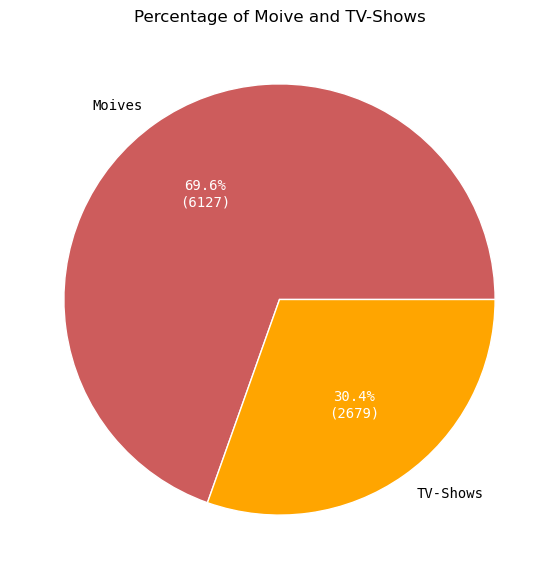

In [62]:
plt.figure(figsize=(7, 7))
wedge, text, autotexts = plt.pie(tv_vs_moive, labels=['Moives', 'TV-Shows'], 
                                 autopct=make_autopct(tv_vs_moive), colors=['indianred', 'orange'], 
                                 textprops={"fontsize": 10, "fontname": 'monospace'}, # 控制 标签文字（labels） 的样式
                                 wedgeprops={"edgecolor": "white", "linewidth": 1, "antialiased": True}) # 控制 每个饼图“扇形楔子” 的样式 (antialiased → 是否抗锯齿（让边缘更平滑）)
print(wedge, text, autotexts)
for autotext in autotexts:
    autotext.set_color("white")
plt.title("Percentage of Moive and TV-Shows")
plt.show()

#### 3.2 The growth of content creation over the years

In [64]:
num_contents = netflix_df.groupby('release_year').size().to_list()
years = np.sort(netflix_df['release_year'].unique())
max_content = max(num_contents)
index = num_contents.index(max_content)

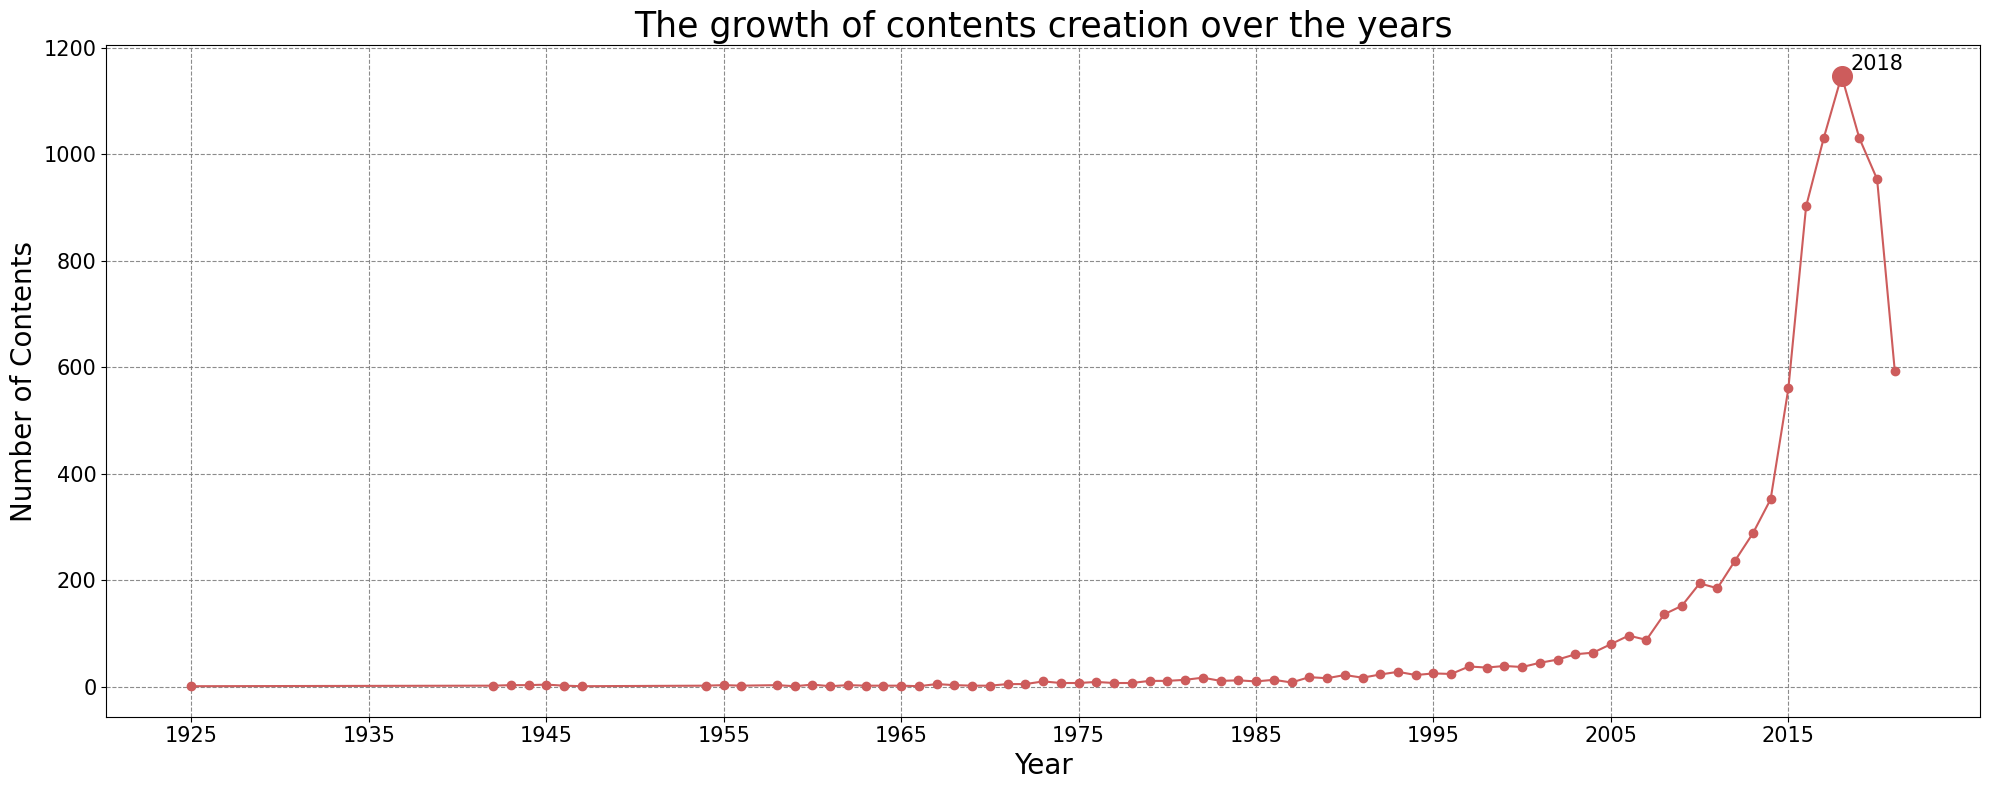

In [65]:
plt.figure(figsize=(20, 8))
plt.plot(years, num_contents, color='indianred', marker='o', markersize=6)
plt.scatter(years[index], max_content, s=200, color='indianred', marker='o')

plt.title("The growth of contents creation over the years", fontsize=25)
plt.xlabel("Year", fontsize=20)
plt.ylabel("Number of Contents", fontsize=20)
plt.xticks(np.arange(min(years), max(years), 10), fontsize=15)
plt.yticks(fontsize=15)
plt.grid(True, alpha=0.9, color='grey', linestyle='--')

plt.text(years[index]+2, max_content + 3, str(years[index]),
         ha='center', va='bottom', fontsize=15)

plt.tight_layout()
plt.show()

The plot shows a steady trend from 1925s to 1985s, and there is a gradute increase for the next 20 years. After that, the contents has rapid climb and reached to the top production in 2018s, and drop sharply after that. 

 #### 3.3 Numer of contents production over the months

In [68]:
# found out there are two entries that have different time format 
netflix_df.loc['s7197', 'date_added'] = '2017-07-10'
netflix_df.loc['s8183', 'date_added'] = '2015-08-28'

netflix_df['month_added'] = pd.to_datetime(netflix_df['date_added'], errors='coerce').dt.month

In [69]:
netflix_df.head()

,type,title,director,cast,country,date_added,release_year,MPA_rating,duration,listed_in,description,month_added
show_id,,,,,,,,,,,,
s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",9
s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",9
s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,9
s4,TV Show,Jailbirds New Orleans,unknown,unknown,unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",9
s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,9


In [70]:
num_contents = netflix_df.groupby('month_added').size().to_list()
months_name = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
max_content = max(num_contents)
index = num_contents.index(max_content)

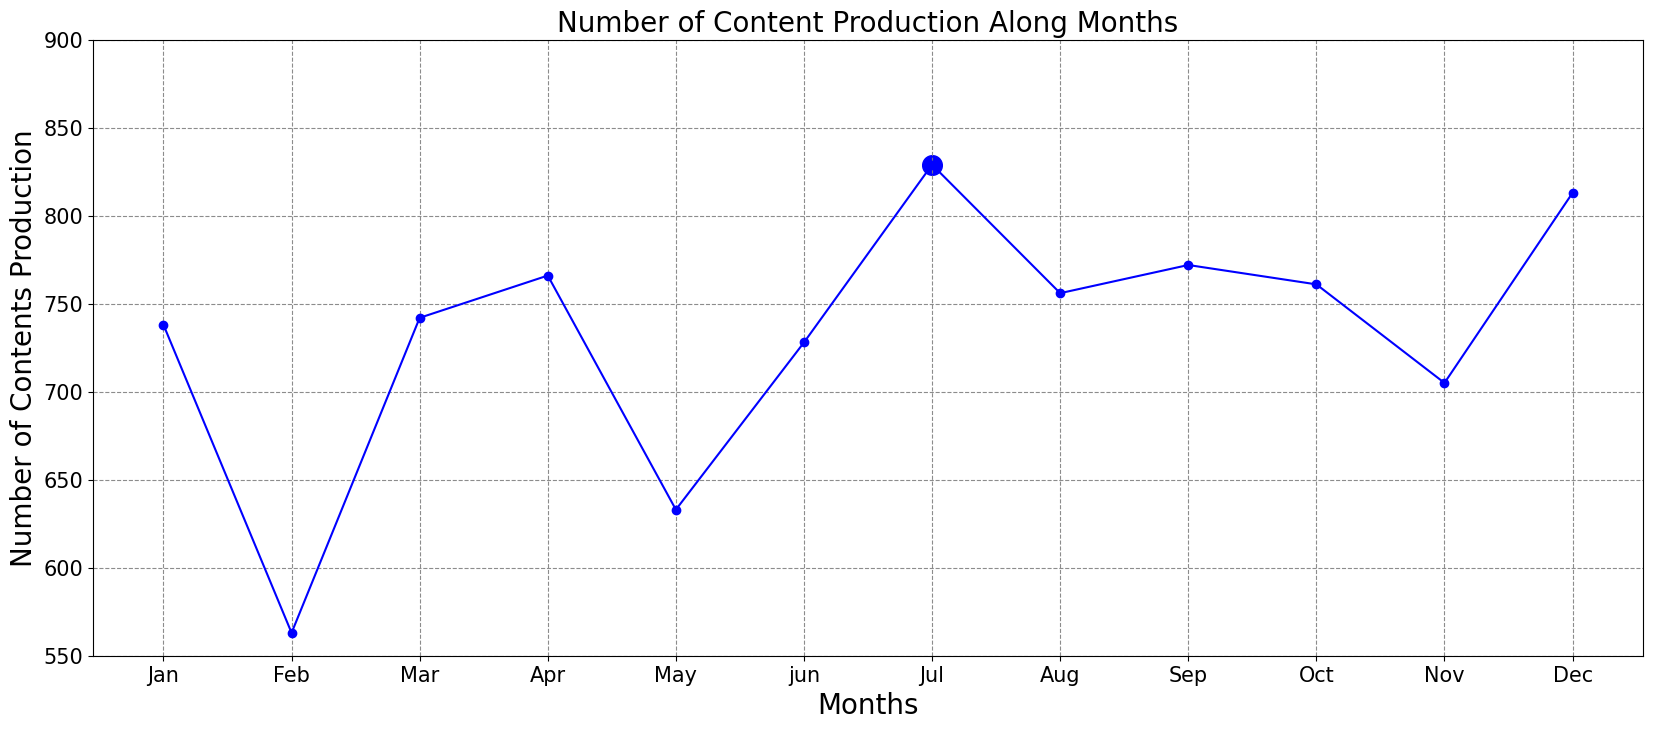

In [71]:
plt.figure(figsize=(20,8))
plt.plot(months_name, num_contents, color='blue', marker='o', markersize=6)
plt.scatter(months_name[index], max_content, s=200, color='blue', marker='o')

plt.title('Number of Content Production Along Months', fontsize=20)
plt.xlabel('Months', fontsize=20)
plt.ylabel('Number of Contents Production', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(True, alpha=0.9, color='grey', linestyle='--')
plt.ylim(550, 900)

plt.show()

The plot shows a fluctuated trend over the periods 

#### 3.4 The Oldest 10 tv-shows and moives

In [74]:
oldest_tv_shows = netflix_df[netflix_df['type'] == 'TV Show'][['title', 'release_year']].sort_values(by='release_year').head(10)
setting_dataframe(oldest_tv_shows)

title,release_year
Pioneers: First Women Filmmakers*,1925
Five Came Back: The Reference Films,1945
Pioneers of African-American Cinema,1946
The Twilight Zone (Original Series),1963
The Andy Griffith Show,1967
Monty Python's Fliegender Zirkus,1972
Monty Python's Flying Circus,1974
Dad's Army,1977
El Chavo,1979
Ninja Hattori,1981


In [75]:
oldest_movies = netflix_df[netflix_df['type'] == 'Movie'][['title', 'release_year']].sort_values(by='release_year').head(10)
setting_dataframe(oldest_movies)

title,release_year
Prelude to War,1942
The Battle of Midway,1942
Why We Fight: The Battle of Russia,1943
Undercover: How to Operate Behind Enemy Lines,1943
WWII: Report from the Aleutians,1943
The Memphis Belle: A Story of a Flying Fortress,1944
The Negro Soldier,1944
Tunisian Victory,1944
Know Your Enemy - Japan,1945
Nazi Concentration Camps,1945


#### 3.5 The highest 10 countries contributed in content production
As we see, many movies or TV shows were filmed in many countries, and we want to take into count all the countires. 
So, we need to get in every movies/TV show and see the countries where they were filmed.

In [77]:
def count_countries(countries_df):
    '''
    This function count the name and number of countries exist in each entry and return the dictionary 
    :param countries_df-> dataframe contains the countries entry
    '''
    countries_dict = {}
    for entry in countries_df:
        country_list = entry.split(', ')
        for country in country_list:
            if country in countries_dict.keys():
                countries_dict[country] += 1
            else:
                countries_dict[country] = 1
                
    return countries_dict

In [78]:
movie_countries = netflix_df[netflix_df['type'] == 'Movie']['country']
tv_countries = netflix_df[netflix_df['type'] == 'TV Show']['country']

movie_dict = count_countries(movie_countries)
tv_dict = count_countries(tv_countries)
# delete those 'unknown' value in the "country" feature contains otherwise it will affect the visualization 
movie_dict.pop('unknown')
tv_dict.pop('unknown')

# see the results in DataFrame
movie_df = pd.DataFrame(movie_dict.items(), columns=['Country', 'Frequency']).sort_values(by="Frequency", ascending=False).reset_index(drop=True)
tv_df = pd.DataFrame(tv_dict.items(), columns=['Country', 'Frequency']).sort_values(by="Frequency", ascending=False).reset_index(drop=True)

In [79]:
setting_dataframe(movie_df)

Country,Frequency
United States,2748
India,962
United Kingdom,532
Canada,319
France,303
Germany,182
Spain,171
Japan,119
China,114
Mexico,111


In [80]:
setting_dataframe(tv_df)

Country,Frequency
United States,941
United Kingdom,272
Japan,199
South Korea,170
Canada,126
France,90
India,84
Taiwan,70
Australia,66
Spain,61


In [81]:
# as we ca see, the order is different for the two dataframe, in order to keep the consistence I've to merge two dataframe 
merged_df = pd.merge(movie_df, tv_df, on='Country', how='outer').head(10)
merged_df.rename(columns={"Frequency_x": "No.Movies", "Frequency_y": "No.TV_Shows"}, inplace=True)
merged_df = merged_df.astype({'No.Movies': 'int64', 'No.TV_Shows': 'int64'})
setting_dataframe(merged_df)

Country,No.Movies,No.TV_Shows
United States,2748,941
India,962,84
United Kingdom,532,272
Canada,319,126
France,303,90
Germany,182,44
Spain,171,61
Japan,119,199
China,114,48
Mexico,111,58


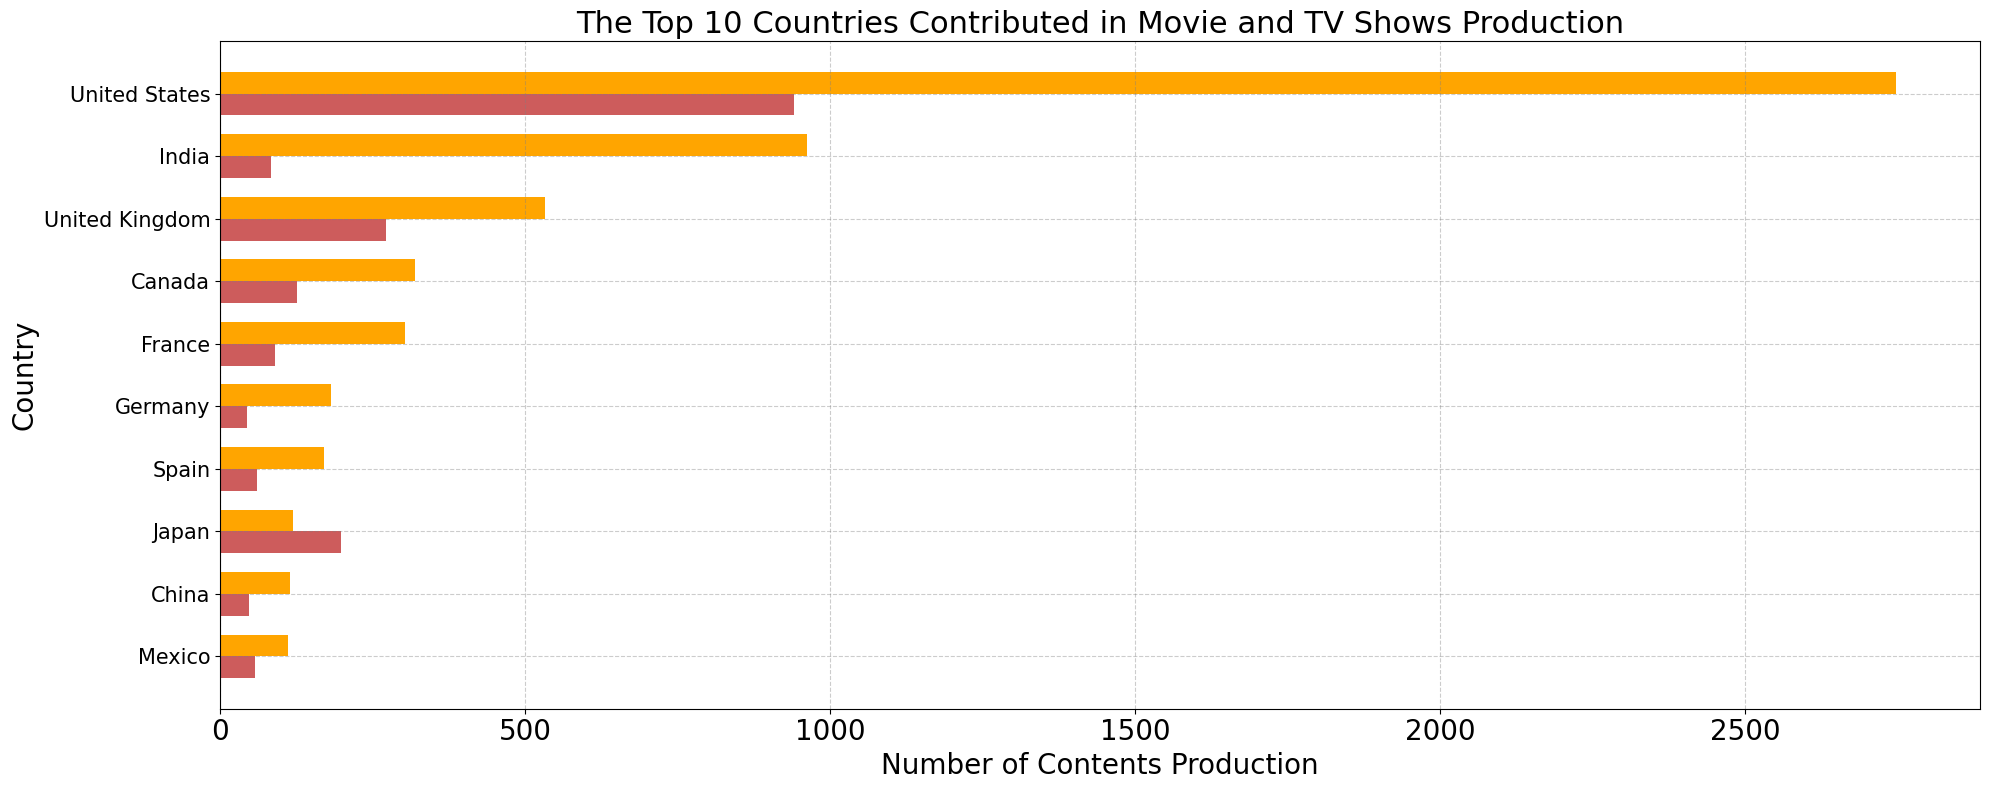

In [82]:
num_movie = merged_df['No.Movies'].to_list()
num_tv = merged_df['No.TV_Shows'].to_list()
countries_name = merged_df['Country'].tolist()

# basic coordinate of y (centrl location for each country)
y = np.arange(len(num_movie))
bar_height = 0.35

plt.figure(figsize=(20,8))
plt.barh(y - bar_height/2, num_movie, height=bar_height, color='orange', label='Movies')
plt.barh(y + bar_height/2, num_tv, height=bar_height, color='indianred', label="TV-shows")

plt.title("The Top 10 Countries Contributed in Movie and TV Shows Production", fontsize=22)
plt.yticks(y, countries_name, fontsize=15)
plt.xticks(fontsize=20)
plt.xlabel("Number of Contents Production", fontsize=20)
plt.ylabel("Country", fontsize=20)
plt.grid(True, alpha=0.4, color='grey', linestyle="--")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### 3.6 The most frequent categories 
I want to see the classification proportion of movies and TV series, respectively 

In [84]:
movie_categories = netflix_df[netflix_df['type'] == 'Movie']['listed_in']

movie_category_dict = {}
for category_entry in movie_categories:
    category_list = category_entry.split(", ")
    for category in category_list:
        if category in movie_category_dict.keys():
            movie_category_dict[category] += 1
        else:
            movie_category_dict[category] = 1

# let see the result in dataframe
movies_category_df = pd.DataFrame(movie_category_dict.items(), columns=['Category', 'Frequency']).sort_values(by='Frequency', ascending=False).reset_index(drop=True)
movies_category_df

,Category,Frequency
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,Documentaries,869
4,Action & Adventure,859
5,Independent Movies,756
6,Children & Family Movies,641
7,Romantic Movies,616
8,Thrillers,577
9,Music & Musicals,375


In [85]:
tv_categories = netflix_df[netflix_df['type'] == 'TV Show']['listed_in']

tv_category_dict = {}
for category_entry in tv_categories:
    category_list = category_entry.split(", ")
    for category in category_list:
        if category in tv_category_dict.keys():
            tv_category_dict[category] += 1
        else:
            tv_category_dict[category] = 1

# let see the result in dataframe
tv_category_df = pd.DataFrame(tv_category_dict.items(), columns=['Category', 'Frequency']).sort_values(by='Frequency', ascending=False).reset_index(drop=True)
tv_category_df

,Category,Frequency
0,International TV Shows,1351
1,TV Dramas,763
2,TV Comedies,581
3,Crime TV Shows,470
4,Kids' TV,451
5,Docuseries,395
6,Romantic TV Shows,370
7,Reality TV,255
8,British TV Shows,253
9,Anime Series,176


0    2752
1    2427
2    1674
3     869
4     859
Name: Frequency, dtype: int64
32.07085430622101
28.283417224884033
19.50821578502655
10.127025097608566
10.010488331317902
0    1351
1     763
2     581
3     470
4     451
Name: Frequency, dtype: int64
37.36172616481781
21.100664138793945
16.06747806072235
12.997788190841675
12.472344934940338


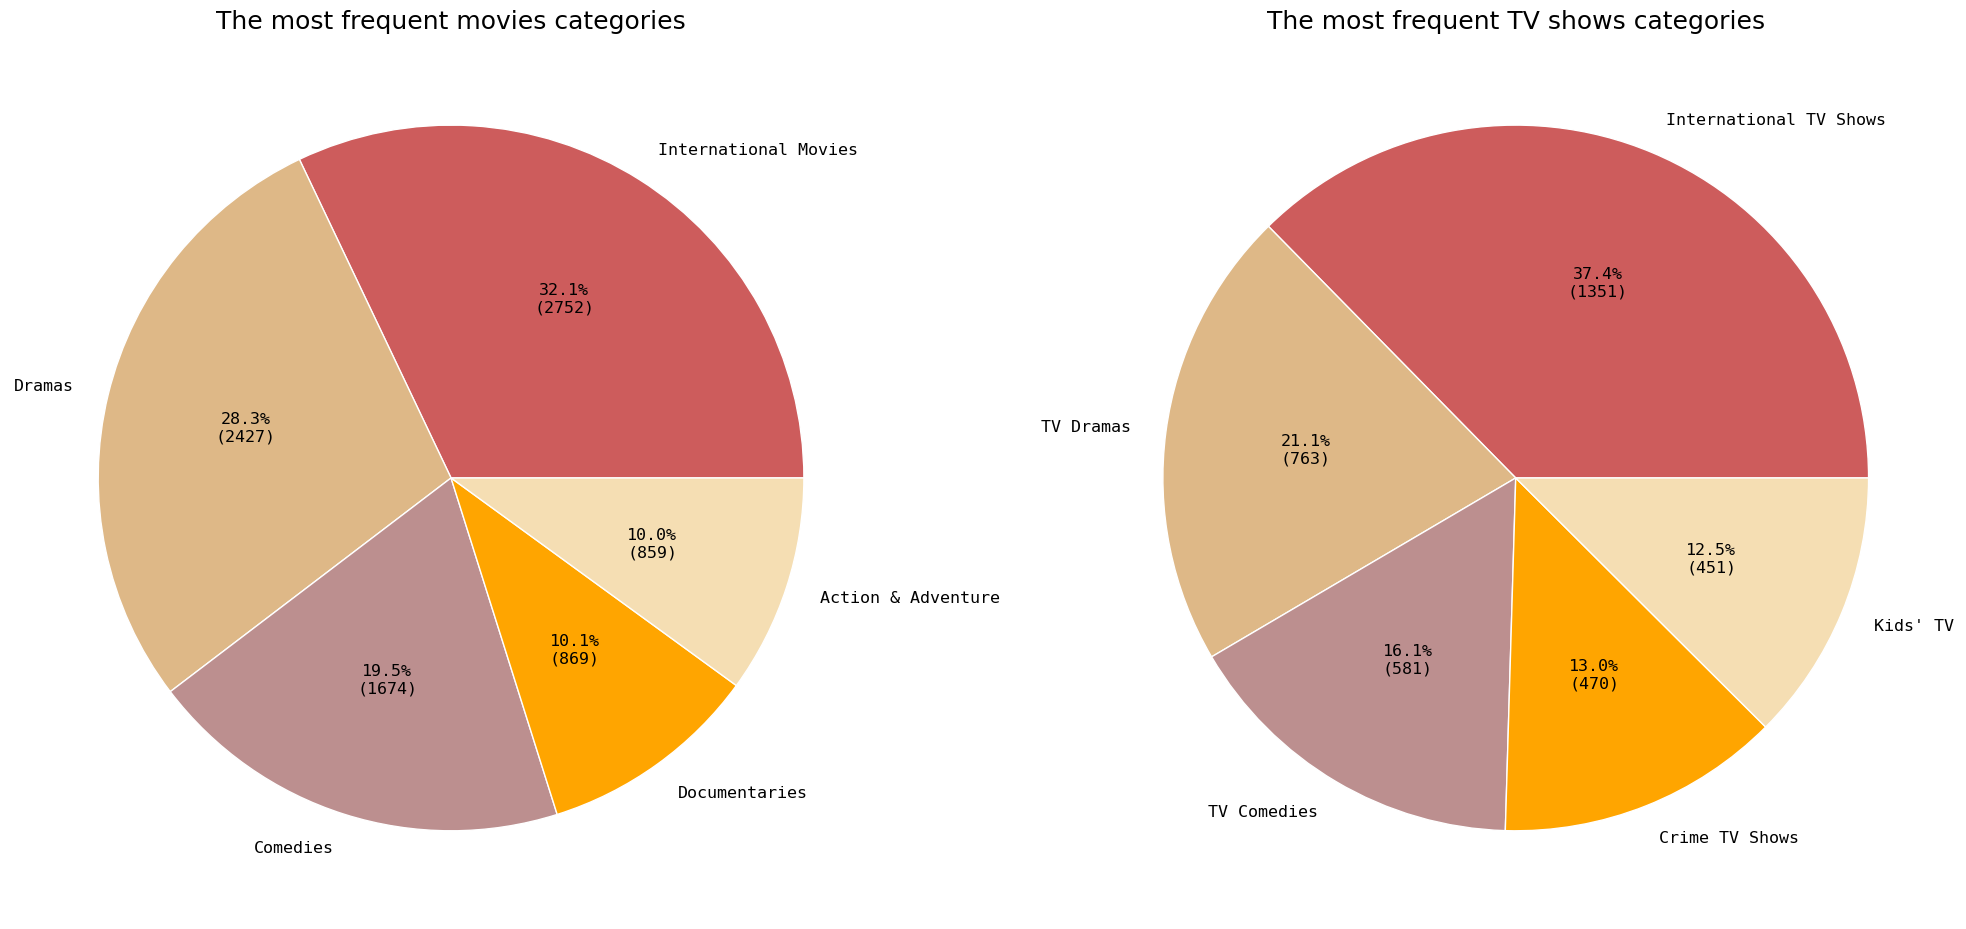

In [86]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20,20))
colors = ['indianred', 'burlywood', 'rosybrown', 'orange', 'wheat']

# movie's category 
top_5_movies = movies_category_df.head(5)
ax[0].pie(top_5_movies['Frequency'], labels=top_5_movies['Category'], colors=colors, 
          autopct=make_autopct(top_5_movies['Frequency']), 
          wedgeprops={'edgecolor': 'white', 'linewidth': 1, 'antialiased': True}, 
          textprops={'fontname': 'monospace', 'fontsize': 12})

ax[0].set_title('The most frequent movies categories', fontsize=18)

# tv shows category
top_5_tv_shows = tv_category_df.head(5)
ax[1].pie(top_5_tv_shows['Frequency'], labels=top_5_tv_shows['Category'], colors=colors, 
          autopct=make_autopct(top_5_tv_shows['Frequency']), 
          wedgeprops={'edgecolor': 'white', 'linewidth': 1, 'antialiased': True}, 
          textprops={'fontname': 'monospace', 'fontsize': 12})
ax[1].set_title('The most frequent TV shows categories', fontsize=18)

plt.tight_layout()
plt.show()